In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)


In [16]:
# Load dataset
df = pd.read_csv("click_fraud_dataset.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (5000, 21)


,click_id,timestamp,user_id,ip_address,device_type,browser,operating_system,referrer_url,page_url,click_duration,scroll_depth,mouse_movement,keystrokes_detected,ad_position,click_frequency,time_since_last_click,device_ip_reputation,VPN_usage,proxy_usage,bot_likelihood_score,is_fraudulent
0,d875835d-3a4a-4a20-b0d1-6cddf89afc6a,2024-08-23 02:47:39,65a2f621-707b-49be-9c3e-ccac0b1d89ef,141.36.49.37,Tablet,Safari,Android,https://evans-ford.com/,http://www.turner-stewart.com/,0.29,60,111,8,Bottom,7,72,Good,0,1,0.29,0
1,a2d3f028-7790-4be1-9f75-df1357edbbdb,2025-01-30 23:23:50,135e0114-76c5-43ea-bdef-80ab537dc009,216.29.19.201,Desktop,Opera,iOS,https://pierce-ferguson.net/,http://www.rodriguez.biz/,0.64,25,452,29,Bottom,9,201,Suspicious,0,0,0.74,0
2,36d787b2-fbce-43ef-8c02-7c8746d7e3db,2025-01-21 05:41:12,a6922984-78cb-4c01-9c88-bfe3a13a0aaf,167.133.41.231,Tablet,Safari,Linux,https://www.martinez.com/,https://beck.biz/,0.42,36,431,18,Bottom,9,326,Good,0,1,0.14,0
3,01fc0078-096b-4f90-82ae-aa8085b719ac,2024-10-12 08:18:14,d30788b2-4048-4770-a4b1-a9358788818f,216.146.33.78,Tablet,Edge,macOS,https://jones-mendoza.com/,https://www.alvarado.com/,4.29,29,472,37,Side,4,33,Suspicious,0,0,0.65,0
4,0afdf2af-0b48-47d5-bfb6-e087053e1eb9,2024-04-19 14:44:35,dfc42287-6325-4344-b373-b8e61ea6e5c1,146.37.54.245,Desktop,Opera,Windows,https://www.griffith-holloway.com/,http://gonzalez.com/,2.46,94,50,2,Side,7,97,Good,0,0,0.06,0


In [17]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   click_id               5000 non-null   object 
 1   timestamp              5000 non-null   object 
 2   user_id                5000 non-null   object 
 3   ip_address             5000 non-null   object 
 4   device_type            5000 non-null   object 
 5   browser                5000 non-null   object 
 6   operating_system       5000 non-null   object 
 7   referrer_url           5000 non-null   object 
 8   page_url               5000 non-null   object 
 9   click_duration         5000 non-null   float64
 10  scroll_depth           5000 non-null   int64  
 11  mouse_movement         5000 non-null   int64  
 12  keystrokes_detected    5000 non-null   int64  
 13  ad_position            5000 non-null   object 
 14  click_frequency        5000 non-null   int64  
 15  time

In [18]:
missing = df.isnull().sum().sort_values(ascending=False)
missing


click_id                 0
timestamp                0
user_id                  0
ip_address               0
device_type              0
browser                  0
operating_system         0
referrer_url             0
page_url                 0
click_duration           0
scroll_depth             0
mouse_movement           0
keystrokes_detected      0
ad_position              0
click_frequency          0
time_since_last_click    0
device_ip_reputation     0
VPN_usage                0
proxy_usage              0
bot_likelihood_score     0
is_fraudulent            0
dtype: int64

In [19]:
# Target column
TARGET_COL = "is_fraudulent"

df[TARGET_COL].value_counts()


is_fraudulent
0    3759
1    1241
Name: count, dtype: int64

In [20]:
fraud_dist = df[TARGET_COL].value_counts(normalize=True) * 100
fraud_dist


is_fraudulent
0    75.18
1    24.82
Name: proportion, dtype: float64

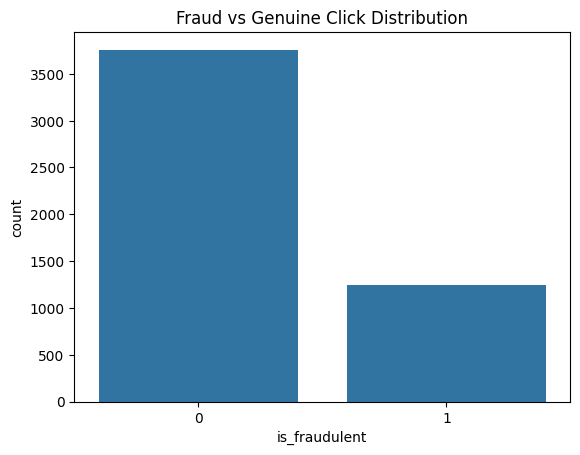

In [21]:
sns.countplot(x=TARGET_COL, data=df)
plt.title("Fraud vs Genuine Click Distribution")
plt.show()



In [22]:
NON_LEARNING_COLS = [
    "click_id",
    "user_id",
    "ip_address",
    "referrer_url",
    "page_url"
]

print("Non-learning columns:")
NON_LEARNING_COLS


Non-learning columns:


['click_id', 'user_id', 'ip_address', 'referrer_url', 'page_url']

In [23]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

categorical_cols, numeric_cols


(['click_id',
  'timestamp',
  'user_id',
  'ip_address',
  'device_type',
  'browser',
  'operating_system',
  'referrer_url',
  'page_url',
  'ad_position',
  'device_ip_reputation'],
 ['click_duration',
  'scroll_depth',
  'mouse_movement',
  'keystrokes_detected',
  'click_frequency',
  'time_since_last_click',
  'VPN_usage',
  'proxy_usage',
  'bot_likelihood_score',
  'is_fraudulent'])

In [24]:
print("Total columns:", len(df.columns))
print("Categorical:", len(categorical_cols))
print("Numeric:", len(numeric_cols))
print("Target:", TARGET_COL)


Total columns: 21
Categorical: 11
Numeric: 10
Target: is_fraudulent


In [25]:
# Columns that should not be used directly for learning
NON_LEARNING_COLS = [
    "click_id",
    "user_id",
    "ip_address",
    "referrer_url",
    "page_url"
]

df_model = df.drop(columns=NON_LEARNING_COLS)

df_model.head()


,timestamp,device_type,browser,operating_system,click_duration,scroll_depth,mouse_movement,keystrokes_detected,ad_position,click_frequency,time_since_last_click,device_ip_reputation,VPN_usage,proxy_usage,bot_likelihood_score,is_fraudulent
0,2024-08-23 02:47:39,Tablet,Safari,Android,0.29,60,111,8,Bottom,7,72,Good,0,1,0.29,0
1,2025-01-30 23:23:50,Desktop,Opera,iOS,0.64,25,452,29,Bottom,9,201,Suspicious,0,0,0.74,0
2,2025-01-21 05:41:12,Tablet,Safari,Linux,0.42,36,431,18,Bottom,9,326,Good,0,1,0.14,0
3,2024-10-12 08:18:14,Tablet,Edge,macOS,4.29,29,472,37,Side,4,33,Suspicious,0,0,0.65,0
4,2024-04-19 14:44:35,Desktop,Opera,Windows,2.46,94,50,2,Side,7,97,Good,0,0,0.06,0


In [26]:
# Convert timestamp to datetime
df_model["timestamp"] = pd.to_datetime(df_model["timestamp"])

# Extract useful time-based features
df_model["click_hour"] = df_model["timestamp"].dt.hour
df_model["click_day"] = df_model["timestamp"].dt.day
df_model["click_weekday"] = df_model["timestamp"].dt.weekday
df_model["is_weekend"] = df_model["click_weekday"].isin([5, 6]).astype(int)

# Drop original timestamp
df_model = df_model.drop(columns=["timestamp"])

df_model.head()


,device_type,browser,operating_system,click_duration,scroll_depth,mouse_movement,keystrokes_detected,ad_position,click_frequency,time_since_last_click,device_ip_reputation,VPN_usage,proxy_usage,bot_likelihood_score,is_fraudulent,click_hour,click_day,click_weekday,is_weekend
0,Tablet,Safari,Android,0.29,60,111,8,Bottom,7,72,Good,0,1,0.29,0,2,23,4,0
1,Desktop,Opera,iOS,0.64,25,452,29,Bottom,9,201,Suspicious,0,0,0.74,0,23,30,3,0
2,Tablet,Safari,Linux,0.42,36,431,18,Bottom,9,326,Good,0,1,0.14,0,5,21,1,0
3,Tablet,Edge,macOS,4.29,29,472,37,Side,4,33,Suspicious,0,0,0.65,0,8,12,5,1
4,Desktop,Opera,Windows,2.46,94,50,2,Side,7,97,Good,0,0,0.06,0,14,19,4,0


In [27]:
TARGET_COL = "is_fraudulent"

X = df_model.drop(columns=[TARGET_COL])
y = df_model[TARGET_COL]

X.shape, y.shape


((5000, 18), (5000,))

In [28]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

categorical_cols, numeric_cols


(['device_type',
  'browser',
  'operating_system',
  'ad_position',
  'device_ip_reputation'],
 ['click_duration',
  'scroll_depth',
  'mouse_movement',
  'keystrokes_detected',
  'click_frequency',
  'time_since_last_click',
  'VPN_usage',
  'proxy_usage',
  'bot_likelihood_score',
  'click_hour',
  'click_day',
  'click_weekday',
  'is_weekend'])

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train.shape, X_test.shape


((4000, 18), (1000, 18))

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)


In [31]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed.shape, X_test_processed.shape


((4000, 32), (1000, 32))

In [32]:
import joblib

joblib.dump(preprocessor, "preprocessor_v3.pkl")
print("Preprocessor saved successfully")


Preprocessor saved successfully


In [33]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

X_train_smote.shape, y_train_smote.value_counts()


((6014, 32),
 is_fraudulent
 1    3007
 0    3007
 Name: count, dtype: int64)

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


In [38]:
ml_models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=2,
        # use_label_encoder=False
    ),
    "LightGBM": LGBMClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(
        verbose=0,
        random_state=2
    )
}


In [39]:
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

ml_results = {}

for name, model in ml_models.items():
    print(f"Training {name}...")
    
    model.fit(X_train_smote, y_train_smote)
    
    y_pred = model.predict(X_test_processed)
    y_proba = model.predict_proba(X_test_processed)[:, 1]
    
    ml_results[name] = {
        "model": model,
        "roc_auc": roc_auc_score(y_test, y_proba),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    }


Training LogisticRegression...
Training DecisionTree...
Training RandomForest...
Training GradientBoosting...
Training KNN...
Training SVM...
Training XGBoost...
Training LightGBM...
[LightGBM] [Info] Number of positive: 3007, number of negative: 3007
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003432 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7216
[LightGBM] [Info] Number of data points in the train set: 6014, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

C:\Users\HANUMAN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\HANUMAN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training CatBoost...


In [40]:
ml_results_df = pd.DataFrame(ml_results).T.drop(columns=["model"])
ml_results_df.sort_values(by="roc_auc", ascending=False)


,roc_auc,precision,recall,f1
DecisionTree,1.0,1.0,1.0,1.0
RandomForest,1.0,1.0,1.0,1.0
GradientBoosting,1.0,1.0,1.0,1.0
XGBoost,1.0,1.0,1.0,1.0
LightGBM,1.0,1.0,1.0,1.0
CatBoost,1.0,1.0,1.0,1.0
LogisticRegression,0.999823,0.953846,1.0,0.976378
SVM,0.99652,0.908397,0.959677,0.933333
KNN,0.903765,0.564103,0.887097,0.689655


In [35]:
best_ml_model_name = ml_results_df["roc_auc"].idxmax()
best_ml_model = ml_results[best_ml_model_name]["model"]

print("Best ML Model:", best_ml_model_name)

joblib.dump(best_ml_model, "best_ml_model_v3.pkl")
print("Best ML model saved")


Best ML Model: DecisionTree
Best ML model saved


In [36]:
best_ml_model_name = "XGBoost"
best_ml_model = ml_results[best_ml_model_name]["model"]

joblib.dump(best_ml_model, "best_ml_model.pkl")

print("Final Best ML Model:", best_ml_model_name)


Final Best ML Model: XGBoost


In [37]:
import joblib
import pandas as pd

best_ml_model = joblib.load("best_ml_model.pkl")
preprocessor = joblib.load("preprocessor_v2.pkl")

print("Best ML model and preprocessor loaded")


Best ML model and preprocessor loaded


C:\Users\HANUMAN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.2.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\HANUMAN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.2.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\HANUMAN\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle es

In [38]:
for col in categorical_cols:
    print(col, "→", df_model[col].unique()[:5])


device_type → ['Tablet' 'Desktop' 'Mobile']
browser → ['Safari' 'Opera' 'Edge' 'Chrome' 'Firefox']
operating_system → ['Android' 'iOS' 'Linux' 'macOS' 'Windows']
ad_position → ['Bottom' 'Side' 'Top']
device_ip_reputation → ['Good' 'Suspicious' 'Bad']


In [39]:
# Exact feature names used during training
expected_columns = X.columns.tolist()
expected_columns


['device_type',
 'browser',
 'operating_system',
 'click_duration',
 'scroll_depth',
 'mouse_movement',
 'keystrokes_detected',
 'ad_position',
 'click_frequency',
 'time_since_last_click',
 'device_ip_reputation',
 'VPN_usage',
 'proxy_usage',
 'bot_likelihood_score',
 'click_hour',
 'click_day',
 'click_weekday',
 'is_weekend']

In [40]:
genuine_sample = {
    "device_type": "Mobile",
    "browser": "Chrome",
    "operating_system": "Android",
    "ad_position": "Top",
    "device_ip_reputation": "Good",

    "click_duration": 40,
    "scroll_depth": 80,
    "mouse_movement": 150,
    "keystrokes_detected": 3,
    "click_frequency": 1,
    "time_since_last_click": 240,
    "VPN_usage": 0,
    "proxy_usage": 0,
    "bot_likelihood_score": 0.08,

    "click_hour": 15,
    "click_day": 10,
    "click_weekday": 3,
    "is_weekend": 0
}


In [41]:
fraud_sample = {
    "device_type": "Desktop",
    "browser": "Chrome",
    "operating_system": "Windows",
    "ad_position": "Top",
    "device_ip_reputation": "Bad",

    "click_duration": 1,
    "scroll_depth": 0,
    "mouse_movement": 0,
    "keystrokes_detected": 0,
    "click_frequency": 30,
    "time_since_last_click": 1,
    "VPN_usage": 1,
    "proxy_usage": 1,
    "bot_likelihood_score": 0.95,

    "click_hour": 2,
    "click_day": 10,
    "click_weekday": 3,
    "is_weekend": 0
}


In [42]:
test_df = pd.DataFrame([genuine_sample, fraud_sample])

# Force column order to match training
test_df = test_df[expected_columns]

test_df.dtypes


device_type               object
browser                   object
operating_system          object
click_duration             int64
scroll_depth               int64
mouse_movement             int64
keystrokes_detected        int64
ad_position               object
click_frequency            int64
time_since_last_click      int64
device_ip_reputation      object
VPN_usage                  int64
proxy_usage                int64
bot_likelihood_score     float64
click_hour                 int64
click_day                  int64
click_weekday              int64
is_weekend                 int64
dtype: object

In [43]:
X_test_processed = preprocessor.transform(test_df)

fraud_probs = best_ml_model.predict_proba(X_test_processed)[:, 1]
pred_labels = best_ml_model.predict(X_test_processed)

results_df = pd.DataFrame({
    "Sample_Type": ["Genuine", "Fraud"],
    "True_Label": [0, 1],
    "Predicted_Label": pred_labels,
    "Fraud_Probability": fraud_probs
})

results_df


,Sample_Type,True_Label,Predicted_Label,Fraud_Probability
0,Genuine,0,0,0.000332
1,Fraud,1,1,0.999668
